In [1]:
# 모듈 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 한글 폰트 설정 (Windows 기본)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 데이터 불러오기
accepted_df = pd.read_csv('./data/accepted_2007_to_2018Q4.csv') # 승인된 대출 건

C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\3139296468.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted_df = pd.read_csv('./data/accepted_2007_to_2018Q4.csv') # 승인된 대출 건


### EDA 시작

In [4]:
# 결측치 세기
accepted_df.isna().sum().sort_values()


id                                                  0
loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
int_rate                                           33
term                                               33
installment                                        33
grade                                              33
issue_d                                            33
sub_grade                                          33
verification_status                                33
home_ownership                                     33
purpose                                            33
url                                                33
pymnt_plan                                         33
loan_status                                        33
addr_state                                         33
fico_range_low                                     33
fico_range_high             

In [5]:
# 복사본 생성
eda1 = accepted_df.copy()

In [6]:
eda1[eda1['loan_amnt'].isna()].isna().sum()

id                                             0
member_id                                     33
loan_amnt                                     33
funded_amnt                                   33
funded_amnt_inv                               33
term                                          33
int_rate                                      33
installment                                   33
grade                                         33
sub_grade                                     33
emp_title                                     33
emp_length                                    33
home_ownership                                33
annual_inc                                    33
verification_status                           33
issue_d                                       33
loan_status                                   33
pymnt_plan                                    33
url                                           33
desc                                          33
purpose             

In [7]:
# 중복 행 확인
eda1.duplicated().sum()

np.int64(0)

In [8]:
# 값이 없는 33개 행 제거
eda1 = eda1[eda1['loan_amnt'].notna()]
eda1[eda1['settlement_date'].notna()].head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
68,68506862,NaN,20000.0,20000.0,20000.0,60 months,13.99,465.27,C,C4,Facilities Coordinator,10+ years,OWN,70000.0,Source Verified,Dec-2015,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,210xx,MD,16.90,0.0,Jun-2001,680.0,684.0,0.0,33.0,NaN,20.0,0.0,31200.0,42.0,35.0,w,0.0,0.0,15473.02,15473.02,2965.17,2592.85,0.00,9915.00,1784.7000,Jan-2017,465.27,NaN,Aug-2018,624.0,620.0,0.0,69.0,1.0,Individual,NaN,NaN,NaN,0.0,0.0,34856.0,2.0,1.0,0.0,0.0,43.0,3656.0,37.0,2.0,3.0,4367.0,41.0,74200.0,0.0,1.0,0.0,3.0,1835.0,18527.0,44.0,0.0,0.0,46.0,174.0,5.0,5.0,0.0,6.0,NaN,13.0,NaN,1.0,6.0,11.0,9.0,19.0,2.0,19.0,32.0,11.0,20.0,0.0,0.0,0.0,2.0,94.3,44.4,0.0,0.0,84200.0,34856.0,33100.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Nov-2017,COMPLETE,Sep-2017,9915.0,55.00,1.0
99,66615254,NaN,7200.0,7200.0,7200.0,36 months,17.27,257.67,D,D3,Department Manager,9 years,OWN,20000.0,Verified,Dec-2015,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,023xx,MA,13.21,1.0,Apr-2003,705.0,709.0,1.0,23.0,NaN,8.0,0.0,7302.0,32.6,17.0,w,0.0,0.0,3767.42,3767.42,2002.17,1041.44,0.00,723.81,130.2858,Dec-2016,257.67,NaN,Jul-2018,549.0,545.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,7302.0,2.0,0.0,1.0,1.0,12.0,0.0,NaN,3.0,4.0,5509.0,33.0,22400.0,2.0,0.0,3.0,5.0,913.0,9831.0,41.8,0.0,0.0,128.0,152.0,5.0,5.0,0.0,5.0,23.0,0.0,23.0,0.0,3.0,4.0,5.0,10.0,2.0,8.0,15.0,4.0,8.0,0.0,0.0,0.0,4.0,94.1,0.0,0.0,0.0

In [9]:
# 공통 전처리
# 문자열 양쪽 공백 제거
for col in eda1.columns:
    if eda1[col].dtype == 'object' or eda1[col].dtype == 'string':
        eda1[col] = eda1[col].str.strip()
    else:
        continue

# 날짜 형식 피처 datetime으로 변환
eda1['issue_d'] = pd.to_datetime(eda1['issue_d'])
eda1['settlement_date'] = pd.to_datetime(eda1['settlement_date'])

# 'dti' 이상치 제거


C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\671124397.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  eda1['issue_d'] = pd.to_datetime(eda1['issue_d'])
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\671124397.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  eda1['settlement_date'] = pd.to_datetime(eda1['settlement_date'])


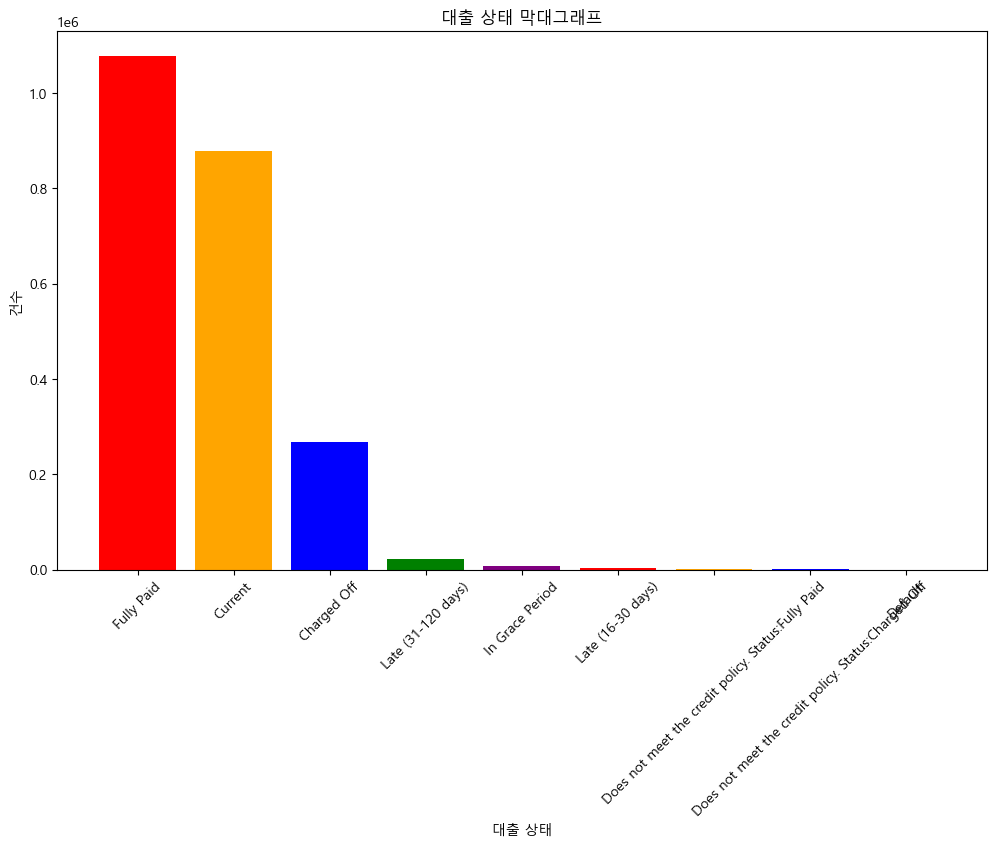

In [10]:
# 종속변수(loan_status) 막대그래프
plt.figure(figsize=(12,7))
plt.title('대출 상태 막대그래프')
plt.bar(eda1['loan_status'].value_counts().index, eda1['loan_status'].value_counts().values, color=['red', 'orange', 'blue', 'green', 'purple'])
plt.xlabel('대출 상태')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.show()



In [11]:
# 36개월 대출과 60개월 대출의 대출 상태 비교

# 대출 승인 날짜 별 36개월 대출 상태 집계

date_term_36 = eda1[eda1['term']=='36 months'].groupby('issue_d')['loan_status'].agg(
    total_count = 'count',
    bad_loan_count = lambda x: (x.isin(['Charged Off', 'Default'])).sum(),
    good_loan_count = lambda x: (x.isin(['Fully Paid'])).sum()
).reset_index()

date_term_36['bad_loan_pct'] = date_term_36['bad_loan_count'] / date_term_36['total_count'] * 100
date_term_36['good_loan_pct'] = date_term_36['good_loan_count'] / date_term_36['total_count'] * 100
date_term_36['diff_pct'] = date_term_36['good_loan_pct'] - date_term_36['bad_loan_pct']
display(date_term_36.head())

# 60개월 대출 상태 집계

date_term_60 = eda1[eda1['term']=='60 months'].groupby('issue_d')['loan_status'].agg(
    total_count = 'count',
    bad_loan_count = lambda x: (x.isin(['Charged Off', 'Default'])).sum(),
    good_loan_count = lambda x: (x.isin(['Fully Paid'])).sum()
).reset_index()

date_term_60['bad_loan_pct'] = date_term_60['bad_loan_count'] / date_term_60['total_count'] * 100
date_term_60['good_loan_pct'] = date_term_60['good_loan_count'] / date_term_60['total_count'] * 100
date_term_60['diff_pct'] = date_term_60['good_loan_pct'] - date_term_60['bad_loan_pct']
display(date_term_60.head())

,issue_d,total_count,bad_loan_count,good_loan_count,bad_loan_pct,good_loan_pct,diff_pct
0,2007-06-01,24,0,1,0.000000,4.166667,4.166667
1,2007-07-01,63,0,30,0.000000,47.619048,47.619048
2,2007-08-01,74,7,26,9.459459,35.135135,25.675676
3,2007-09-01,53,3,15,5.660377,28.301887,22.641509
4,2007-10-01,105,10,37,9.523810,35.238095,25.714286


,issue_d,total_count,bad_loan_count,good_loan_count,bad_loan_pct,good_loan_pct,diff_pct
0,2010-05-01,182,36,131,19.780220,71.978022,52.197802
1,2010-06-01,466,101,324,21.673820,69.527897,47.854077
2,2010-07-01,419,72,304,17.183771,72.553699,55.369928
3,2010-08-01,459,86,323,18.736383,70.370370,51.633987
4,2010-09-01,457,106,307,23.194748,67.177243,43.982495


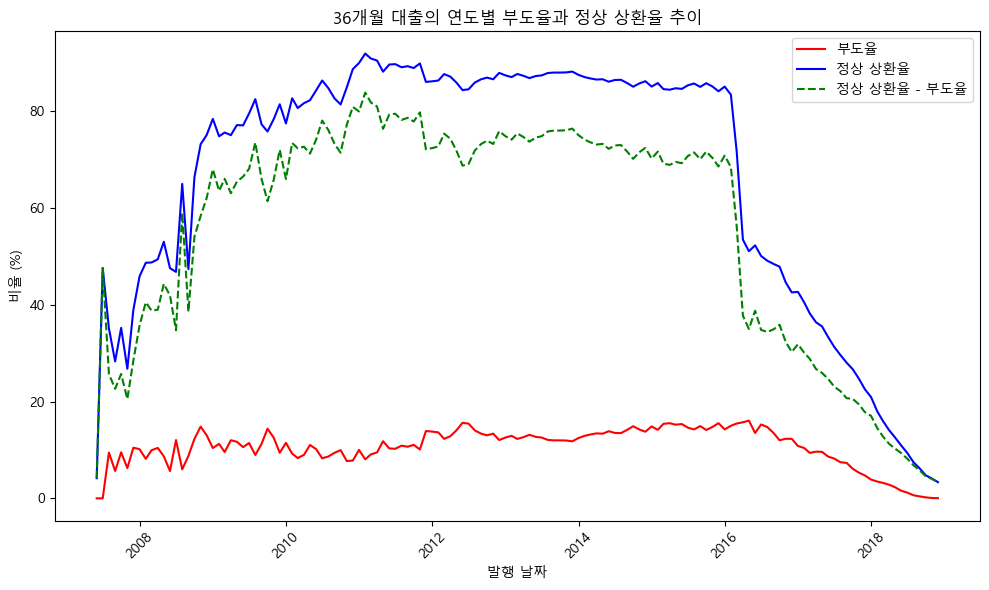

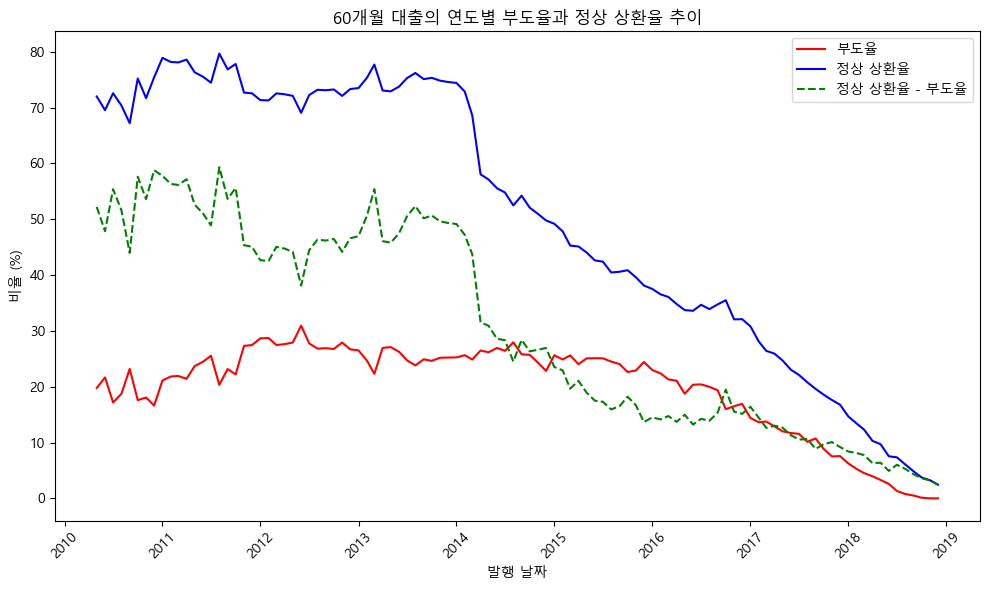

In [12]:
# 36개월 대출과 60개월 대출의 부도율과 정상 상환율 추이 시각화

fig,ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=date_term_36, x='issue_d', y='bad_loan_pct', color='red', label='부도율')
sns.lineplot(data=date_term_36, x='issue_d', y='good_loan_pct', color='blue', label='정상 상환율')
sns.lineplot(data=date_term_36, x='issue_d', y='diff_pct', color='green', label='정상 상환율 - 부도율', linestyle='--')
ax.set_title('36개월 대출의 연도별 부도율과 정상 상환율 추이')
ax.set_xlabel('발행 날짜')
ax.set_ylabel('비율 (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=date_term_60, x='issue_d', y='bad_loan_pct', color='red', label='부도율')
sns.lineplot(data=date_term_60, x='issue_d', y='good_loan_pct', color='blue', label='정상 상환율')
sns.lineplot(data=date_term_60, x='issue_d', y='diff_pct', color='green', label='정상 상환율 - 부도율', linestyle='--')
ax.set_title('60개월 대출의 연도별 부도율과 정상 상환율 추이')
ax.set_xlabel('발행 날짜')
ax.set_ylabel('비율 (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,grade,total_count,bad_loan_count,good_loan_count,bad_loan_pct,good_loan_pct
0,A,433027,14206,220889,3.280627,51.010445
1,B,663557,52576,340172,7.923359,51.264925
2,C,650053,85657,296037,13.176926,45.540441
3,D,324424,61067,139899,18.823207,43.122272
4,E,135639,36041,57615,26.571266,42.476721
5,F,41800,14492,17567,34.669856,42.026316
6,G,12168,4560,4572,37.475345,37.573964


Text(0.5, 1.0, '신용 등급 별 부도율과 정상 상환율')

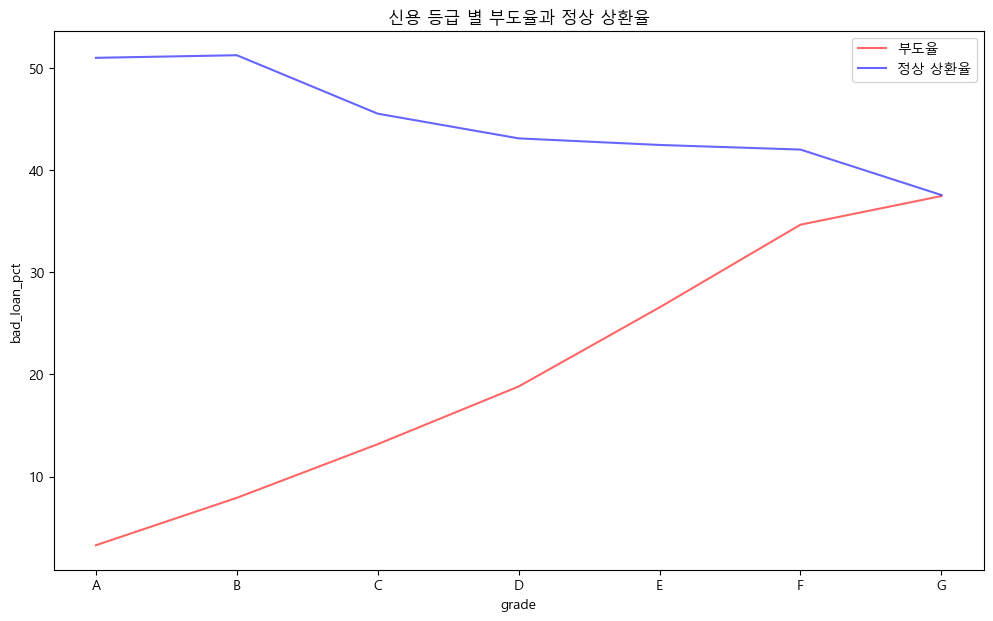

In [13]:
# 신용 등급 별 상환율 계산
credit_grade_summary = eda1.groupby('grade')['loan_status'].agg(
    total_count = 'count',
    bad_loan_count = lambda x: (x.isin(['Charged Off','Default'])).sum(),
    good_loan_count = lambda x: (x.isin(['Fully Paid'])).sum()
).reset_index()

credit_grade_summary['bad_loan_pct'] = credit_grade_summary['bad_loan_count'] / credit_grade_summary['total_count'] * 100
credit_grade_summary['good_loan_pct'] = credit_grade_summary['good_loan_count'] / credit_grade_summary['total_count'] * 100
display(credit_grade_summary)

# 신용 등급 별 상환율 시각화
plt.figure(figsize=(12,7))
sns.lineplot(data=credit_grade_summary, x='grade', y='bad_loan_pct', color='red', label='부도율', alpha=0.6)
sns.lineplot(data=credit_grade_summary, x='grade', y='good_loan_pct', color='blue', label='정상 상환율', alpha=0.6)
plt.title('신용 등급 별 부도율과 정상 상환율')

대출 상태
```
• Fully Paid: 완전 상환
• Charged Off: 상각/부도 처리
• Default: 채무불이행
• Current: 현재 상환 중
• Late (31-120 days): 31-120일 연체
• Late (16-30 days): 16-30일 연체
• In Grace Period: 유예 기간 (납부일이 지났지만 아직 공식적인 연체로 분류되기 전의 상태)
• Does not meet the credit policy. Status:Fully Paid: 현재 신용 정책 기준을 충족하지 않지만, 대출이 완전히 상환된 케이스
• Does not meet the credit policy. Status:Charged Off : 현재 신용 정책 기준을 충족하지 않으며, 결국 부도 처리된 케이스
```

In [14]:
# loan_status 이진 분류
# 0: Fully Paid (정상 상환)
# 1: Charged Off (부도)

mapping = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Defult': 1,
}

eda1['loan_status_binary'] = eda1['loan_status'].map(mapping)
pre1 = eda1[eda1['loan_status_binary'].notna()]
display(pre1[['loan_status', 'loan_status_binary']].head())


,loan_status,loan_status_binary
0,Fully Paid,0.0
1,Fully Paid,0.0
2,Fully Paid,0.0
4,Fully Paid,0.0
5,Fully Paid,0.0


In [15]:
pre1.shape

(1345310, 152)

In [16]:
#plt.figure(figsize=(20,15))
#sns.scatterplot(data=pre1, x='loan_amnt', y='annual_inc', hue='loan_status_binary', alpha=0.5)
#plt.title('대출 금액과 연소득의 관계')
#plt.xlabel('대출 금액')
#plt.ylabel('연소득')
#plt.legend(title='대출 상태 (0: 정상 상환, 1: 부도)')
#plt.show()

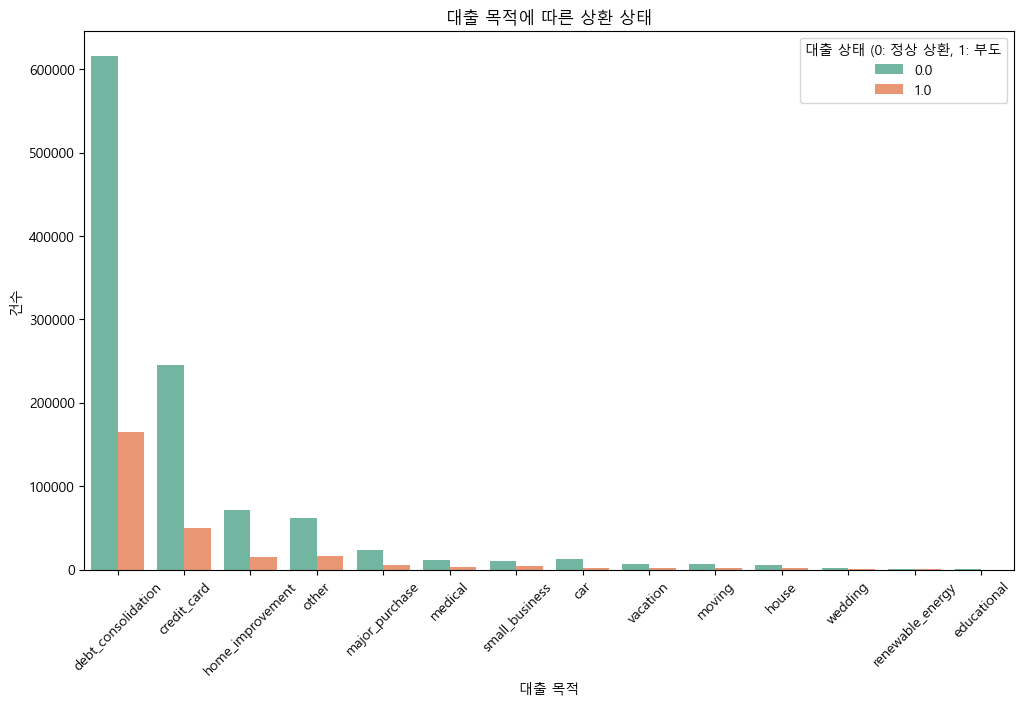

In [17]:
# 대출 목적에 따른 상환 상태 막대그래프
plt.figure(figsize=(12,7))
sns.countplot(data=eda1, x='purpose', hue='loan_status_binary', palette='Set2', order=eda1['purpose'].value_counts().index)
plt.title('대출 목적에 따른 상환 상태')
plt.xlabel('대출 목적')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.legend(title='대출 상태 (0: 정상 상환, 1: 부도')
plt.show()


In [18]:
# 박스플롯 이상치 탐색
def boxplot_outliers(data, x):
    q1 = data[x].quantile(0.25)
    q3 = data[x].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[x] < lower_bound) | (data[x] > upper_bound)]
    return outliers

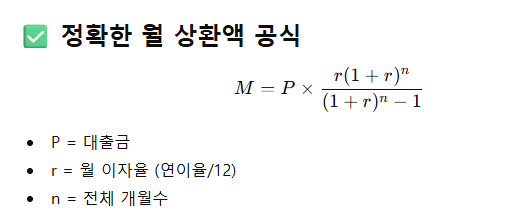

In [36]:
aa = pre1.copy()
aa['dti2'] = (aa['installment']/(aa['annual_inc']/12)*100)
display(aa[['dti','dti2']].head())

term_mapping = {
    '36 months' : 36,
    '60 months' : 60
}

aa['term']=aa['term'].map(term_mapping)
r = aa['int_rate'] / 100 / 12
n = aa['term']
P = aa['funded_amnt']
aa['installment2'] = P * (r * (1+r)**n) / ((1+r)**n - 1)
display(aa[['installment','installment2']].head())

,dti,dti2
0,5.91,2.684291
1,16.06,15.143631
2,10.78,8.241143
4,25.37,3.331246
5,10.20,14.300471


,installment,installment2
0,123.03,123.021983
1,820.28,820.275485
2,432.66,432.657361
4,289.91,289.903895
5,405.18,405.179973


In [20]:
pre1['revol_bal'].unique()

array([  2765.,  21470.,   7869., ..., 100372., 107747.,  77480.],
      shape=(83810,))

In [21]:
pre1.isna().sum().sort_values()

funded_amnt                                         0
loan_amnt                                           0
term                                                0
funded_amnt_inv                                     0
int_rate                                            0
installment                                         0
sub_grade                                           0
grade                                               0
verification_status                                 0
issue_d                                             0
annual_inc                                          0
home_ownership                                      0
purpose                                             0
url                                                 0
pymnt_plan                                          0
loan_status                                         0
fico_range_high                                     0
fico_range_low                                      0
earliest_cr_line            

C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\435183115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pre1, y='loan_amnt', ax=axes[0, 0], palette='Set2', label=f'{boxplot_outliers(pre1, "loan_amnt").shape[0]}개 이상치')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\435183115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pre1, y='int_rate', ax=axes[0, 1], palette='Set2', label=f'{boxplot_outliers(pre1, "int_rate").shape[0]}개 이상치')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\435183115.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

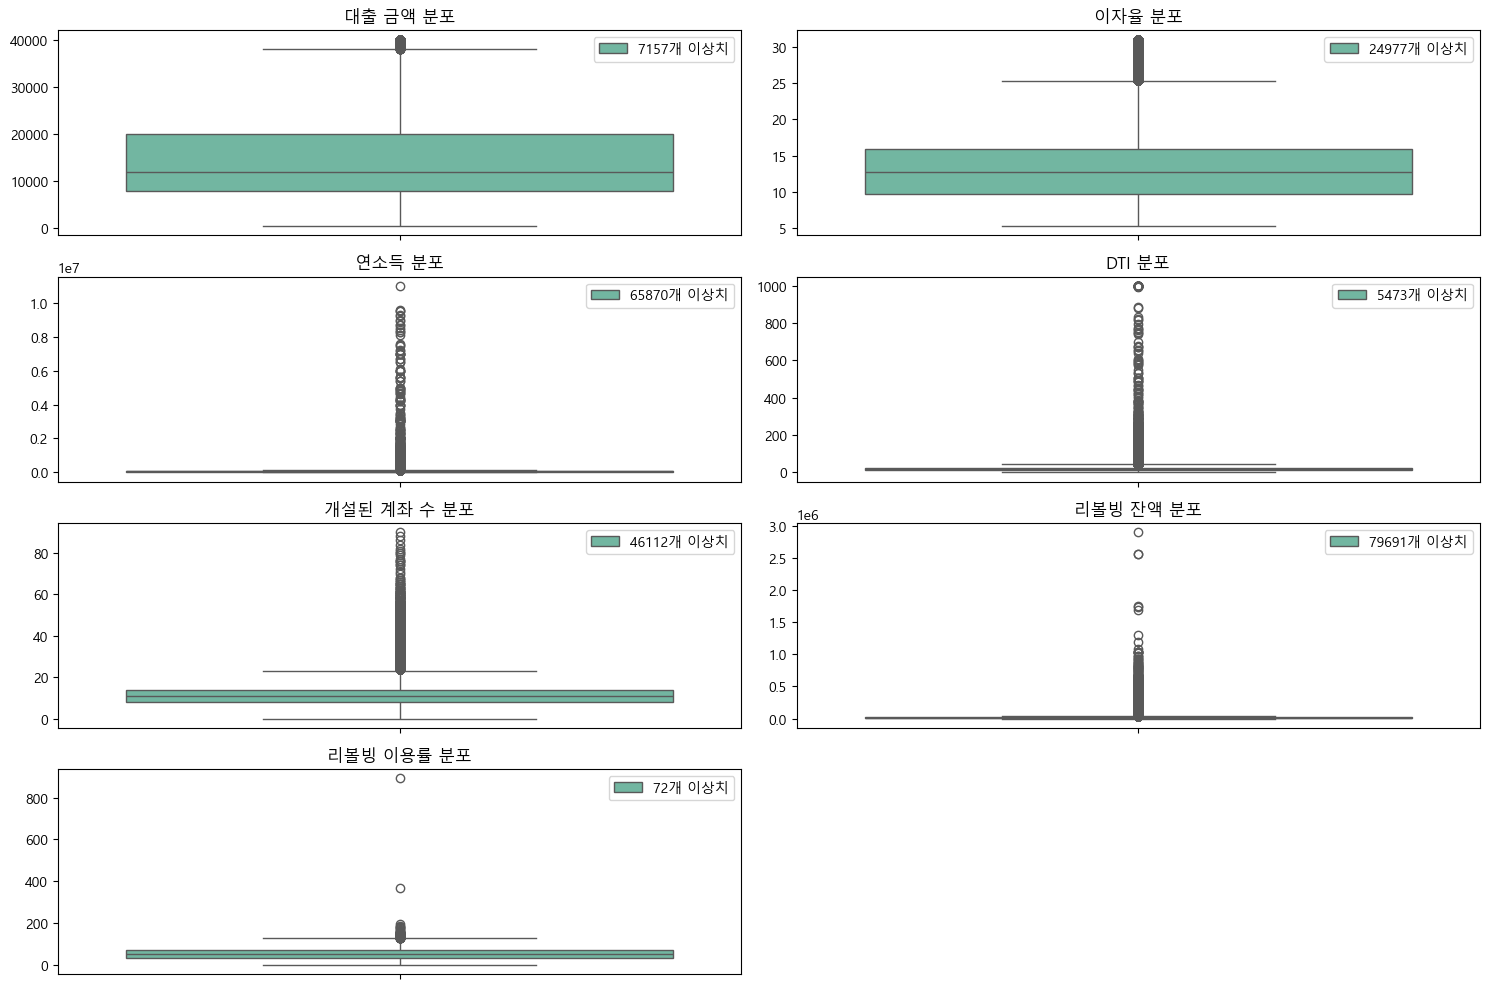

In [22]:
# 주요피처 별 박스플롯 비교 (loan_amnt, int_rate, annual_inc, dti, open_acc, revol_bal, revol_util)
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
sns.boxplot(data=pre1, y='loan_amnt', ax=axes[0, 0], palette='Set2', label=f'{boxplot_outliers(pre1, "loan_amnt").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='int_rate', ax=axes[0, 1], palette='Set2', label=f'{boxplot_outliers(pre1, "int_rate").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='annual_inc', ax=axes[1, 0], palette='Set2', label=f'{boxplot_outliers(pre1, "annual_inc").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='dti', ax=axes[1, 1], palette='Set2', label=f'{boxplot_outliers(pre1, "dti").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='open_acc', ax=axes[2, 0], palette='Set2', label=f'{boxplot_outliers(pre1, "open_acc").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='revol_bal', ax=axes[2, 1], palette='Set2', label=f'{boxplot_outliers(pre1, "revol_bal").shape[0]}개 이상치')
sns.boxplot(data=pre1, y='revol_util', ax=axes[3, 0], palette='Set2', label=f'{boxplot_outliers(pre1, "revol_util").shape[0]}개 이상치')
axes[0, 0].set_title('대출 금액 분포')
axes[0, 1].set_title('이자율 분포')
axes[1, 0].set_title('연소득 분포')
axes[1, 1].set_title('DTI 분포')
axes[2, 0].set_title('개설된 계좌 수 분포')
axes[2, 1].set_title('리볼빙 잔액 분포')
axes[3, 0].set_title('리볼빙 이용률 분포')
axes[3, 1].set_visible(False)  # 마지막 빈 공간 제거
for ax in axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend()
plt.tight_layout()
plt.show()
    

C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\1895676380.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=pre1, x='loan_amnt', ax=axes[0, 0], kde=True, palette='Set2')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\1895676380.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=pre1, x='int_rate', ax=axes[0, 1], kde=True, palette='Set2')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\1895676380.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=pre1, x='annual_inc', ax=axes[1, 0], kde=True, palette='Set2')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\1895676380.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=pre1, x='dti', ax=axes[1, 1], kde=True, palette='Set2')
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\1895676380.py:7: UserWarning: Ignoring `palette

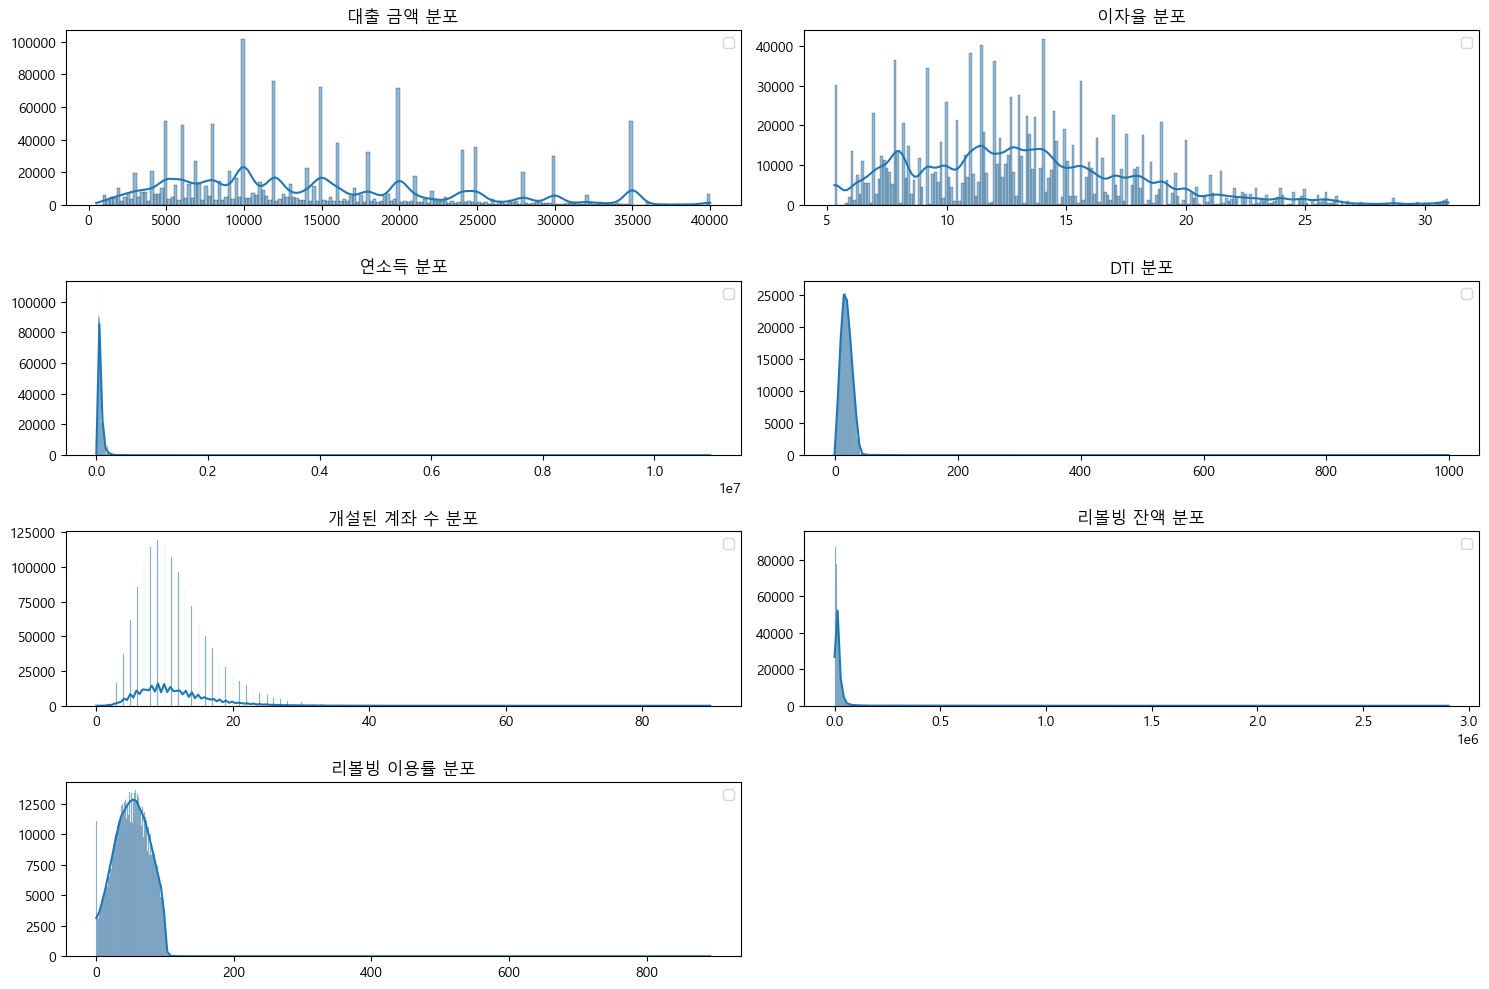

In [23]:

# 주요피처 별 정규분포 그래프 비교 (loan_amnt, int_rate, annual_inc, dti, open_acc, revol_bal, revol_util)
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
sns.histplot(data=pre1, x='loan_amnt', ax=axes[0, 0], kde=True, palette='Set2')
sns.histplot(data=pre1, x='int_rate', ax=axes[0, 1], kde=True, palette='Set2')
sns.histplot(data=pre1, x='annual_inc', ax=axes[1, 0], kde=True, palette='Set2')
sns.histplot(data=pre1, x='dti', ax=axes[1, 1], kde=True, palette='Set2')
sns.histplot(data=pre1, x='open_acc', ax=axes[2, 0], kde=True, palette='Set2')
sns.histplot(data=pre1, x='revol_bal', ax=axes[2, 1], kde=True, palette='Set2')
sns.histplot(data=pre1, x='revol_util', ax=axes[3, 0], kde=True, palette='Set2')
axes[0, 0].set_title('대출 금액 분포')
axes[0, 1].set_title('이자율 분포')
axes[1, 0].set_title('연소득 분포')
axes[1, 1].set_title('DTI 분포')
axes[2, 0].set_title('개설된 계좌 수 분포')
axes[2, 1].set_title('리볼빙 잔액 분포')
axes[3, 0].set_title('리볼빙 이용률 분포')
axes[3, 1].set_visible(False)  # 마지막 빈 공간 제거
for ax in axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend()
plt.tight_layout()
plt.show()
    

### 파생피처 만들기

C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\433846981.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  pre1['emp_length'].fillna('Unknown', inplace=True)
C:\Users\gmltk\AppData\Local\Temp\ipykernel_143024\433846981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

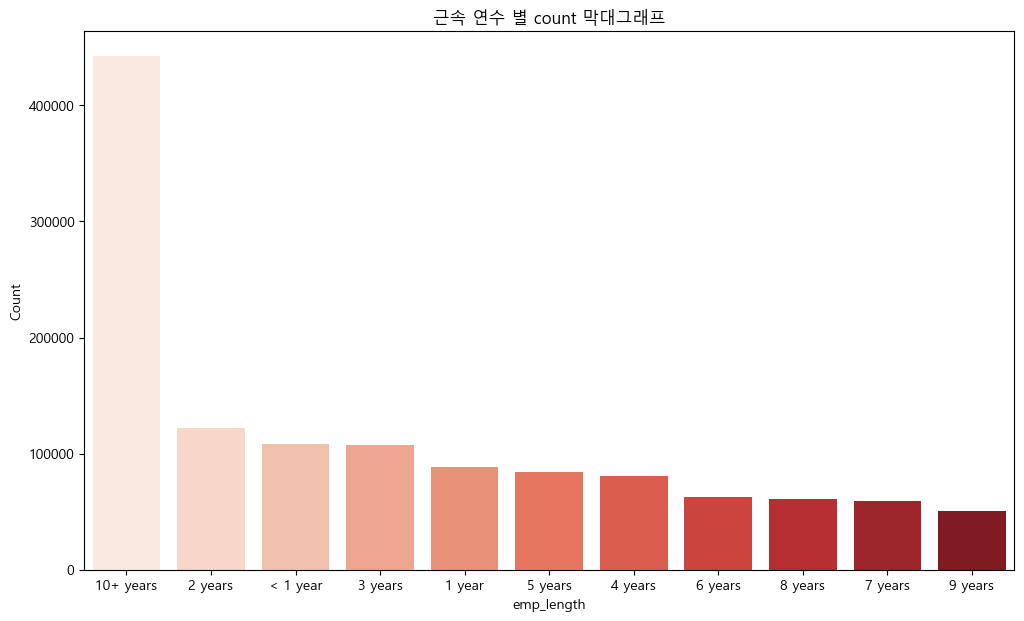

In [24]:
# 간단 시각화
pre1['emp_length'].fillna('Unknown', inplace=True)
plt.figure(figsize=(12,7))
sns.barplot(x='emp_length', y='count', data=pre1.groupby('emp_length').size().reset_index(name='count'), palette='Reds', order=pre1['emp_length'].value_counts().index)
plt.xlabel('emp_length')
plt.ylabel('Count')
plt.title('근속 연수 별 count 막대그래프')
plt.show()


In [25]:
# employee_length_summary = pre1.groupby('emp_length')['loan_status_binary'].agg(
#     count = 'count',
#     charged_off = lambda x: (x == 1).sum(),
#     fully_paid = lambda x: (x == 0).sum(),
# ).reset_index()

# figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
# sns.barplot(data=employee_length_summary, x='emp_length', y='charged_off', ax=ax1, color='orange',order=employee_length_summary.sort_values('charged_off', ascending=False)['emp_length'])
# sns.barplot(data=employee_length_summary, x='emp_length', y='fully_paid', ax=ax2, color='skyblue', order=employee_length_summary.sort_values('fully_paid', ascending=False)['emp_length'])
# ax1.set_title('근속 연수 별 부도 건수')
# ax2.set_title('근속 연수 별 정상 상환 건수')
# ax1.set_xlabel('근속 연수')
# ax1.set_ylabel('부도 건수')
# ax2.set_xlabel('근속 연수')
# ax2.set_ylabel('정상 상환 건수')
# ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
# ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
# plt.tight_layout()
# plt.show()

In [26]:
# 근속연수 별 이자율 시각화
# employee_length_interest = pre1.groupby('emp_length')['int_rate'].agg(
#     mean_int_rate = 'mean'
# ).reset_index()
# plt.figure(figsize=(12,7))
# sns.barplot(data=employee_length_interest, x='emp_length', y='mean_int_rate',order=employee_length_interest.sort_values('mean_int_rate', ascending=False)['emp_length'], color='skyblue')
# plt.title('근속 연수 별 평균 이자율')
# plt.xlabel('근속 연수')
# plt.ylabel('평균 이자율')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [27]:
# 파생변수 아이디어
# 1. 대출 금액 대비 연소득 비율 (loan_amnt / annual_inc)
pre1['loan_to_income_ratio'] = pre1['loan_amnt'] / pre1['annual_inc']
display(pre1[['loan_amnt', 'annual_inc', 'loan_to_income_ratio']].head())
pre1['emp_title'].unique().shape

# 2. 연 소득 로그변환
pre1['log_annual_inc'] = np.log(pre1['annual_inc'] + 1)  # 로그 변환 (0인 경우를 대비해 1을 더함)

# 3. 연체이력


,loan_amnt,annual_inc,loan_to_income_ratio
0,3600.0,55000.0,0.065455
1,24700.0,65000.0,0.380000
2,20000.0,63000.0,0.317460
4,10400.0,104433.0,0.099585
5,11950.0,34000.0,0.351471


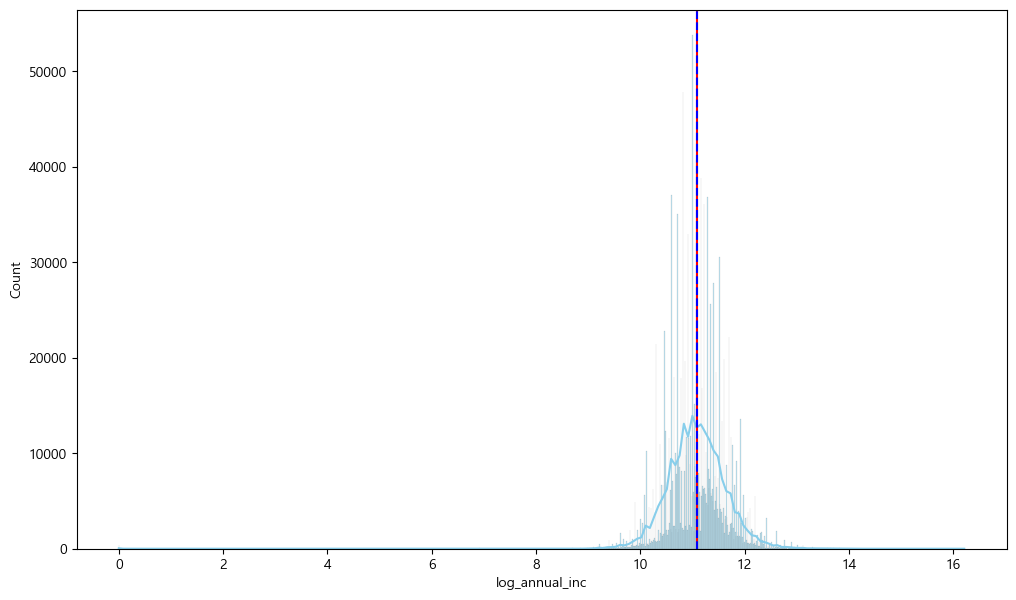

In [34]:
# 로그변환 히스토그램
log_mean = pre1['log_annual_inc'].mean()
log_median = pre1['log_annual_inc'].median()

plt.figure(figsize=(12,7))
sns.histplot(data=pre1, x='log_annual_inc', kde=True, color='skyblue')
plt.axvline(log_mean, linestyle='-', color='red')
plt.axvline(log_median, linestyle='--', color='blue')



In [29]:
pre1['emp_length'].isna().sum()

np.int64(78511)

In [30]:
pre1['emp_length'].unique()

<StringArray>
['10+ years',   '3 years',   '4 years',   '6 years',   '7 years',   '8 years',
   '2 years',   '5 years',   '9 years',  '< 1 year',    '1 year',         nan]
Length: 12, dtype: str

In [31]:
# 지도시각화 코드 예시

# import geopandas as gpd
# import pandas as pd
# import folium

# # 1) shp 로드
# gdf = gpd.read_file("./data/world/tl_2025_us_state.shp")

# # 2) 미국 50주 + DC만 필터
# gdf = gdf[gdf["STUSPS"].isin([
# 'PA','SD','IL','GA','MN','SC','RI','NC','CA','VA','AZ','IN','MD',
# 'NY','TX','KS','NM','AL','WA','OH','LA','FL','CO','MI','MO','DC',
# 'MA','WI','HI','VT','NJ','DE','TN','NH','NE','OR','CT','AR','NV',
# 'WV','MT','WY','OK','KY','MS','UT','ND','ME','AK','ID','IA'
# ])]

# # 3) 부도 건수 집계
# bad = eda1.loc[eda1["loan_status"] == 'Charged Off']
# cnt = bad["addr_state"].value_counts().reset_index()
# cnt.columns = ["STUSPS", "charged_off_cnt"]

# # 4) merge
# gdf = gdf.merge(cnt, on="STUSPS", how="left")
# gdf["charged_off_cnt"] = gdf["charged_off_cnt"].fillna(0)

# # 5) 좌표계 변환 (Folium용)
# gdf = gdf.to_crs(epsg=4326)

# # 6) 지도 생성
# m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="cartodbpositron")

# folium.Choropleth(
#     geo_data=gdf,
#     data=gdf,
#     columns=["STUSPS", "charged_off_cnt"],
#     key_on="feature.properties.STUSPS",
#     fill_color="YlOrRd",
#     fill_opacity=0.8,
#     line_opacity=0.2,
#     legend_name="Charged Off Count"
# ).add_to(m)

# folium.GeoJson(
#     gdf,
#     tooltip=folium.GeoJsonTooltip(
#         fields=["NAME", "charged_off_cnt"],
#         aliases=["State", "Charged Off Count"]
#     )
# ).add_to(m)

# m